ARIMA Modeling for Apple Stock Prediction

To build an ARIMA model to predict future stock returns for Apple and evaluate its performance in capturing market dynamics.

Import Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

Data Loading and Preparation

In this step, we load the historical stock data and prepare it for time-series modeling by converting the Date column and setting it as the index.

In [141]:
df = pd.read_csv("../../data/Apple.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close  Adj Close       Volume
Date                                                          
2015-01-02  27.85  27.86  26.84  27.33      24.21  212,818,400
2015-01-05  27.07  27.16  26.35  26.56      23.53  257,142,000
2015-01-06  26.64  26.86  26.16  26.57      23.53  263,188,400
2015-01-07  26.80  27.05  26.67  26.94      23.86  160,423,600
2015-01-08  27.31  28.04  27.17  27.97      24.78  237,458,000


Create Returns

In [43]:
df['Return'] = df['Close'].pct_change()

df = df.dropna().copy()

print(df[['Close', 'Return']].head())

            Close    Return
Date                       
2015-01-05  26.56 -0.028174
2015-01-06  26.57  0.000377
2015-01-07  26.94  0.013925
2015-01-08  27.97  0.038233
2015-01-09  28.00  0.001073


Train-Test Split

The dataset is split based on time to prevent data leakage.

- Training Data: 2015–2023
- Testing Data: 2024 onwards

This ensures that the model is evaluated on future unseen data.

In [44]:
train = df[df.index < "2024-01-01"].copy()
test = df[df.index >= "2024-01-01"].copy()

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2263
Test size: 541


ARIMA Function

In [45]:
def walk_forward_arima(train_series, test_series):
    
    history = list(train_series.copy())
    predictions = []
    
    for t in range(len(test_series)):
        model = ARIMA(history, order=(1,1,1))
        model_fit = model.fit()
        
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        
        history.append(test_series.iloc[t])
    
    return pd.Series(predictions, index=test_series.index)

Train Model + Predict

In [46]:
train_series = train['Return']
test_series = test['Return']

predictions = walk_forward_arima(train_series, test_series)

print(predictions.head())

Date
2024-01-02    0.001495
2024-01-03    0.003747
2024-01-04    0.001597
2024-01-05    0.001957
2024-01-08    0.001316
dtype: float64


Model Evaluation

The model is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Directional Accuracy

These metrics help assess prediction accuracy and the model's ability to capture market direction.

In [47]:
mae = mean_absolute_error(test_series, predictions)
rmse = np.sqrt(mean_squared_error(test_series, predictions))

directional_accuracy = np.mean(
    (np.sign(predictions) == np.sign(test_series)).astype(int)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("Directional Accuracy:", directional_accuracy)

MAE: 0.011739055756601396
RMSE: 0.017712817713623753
Directional Accuracy: 0.49353049907578556


Plot Actual vs Predicted

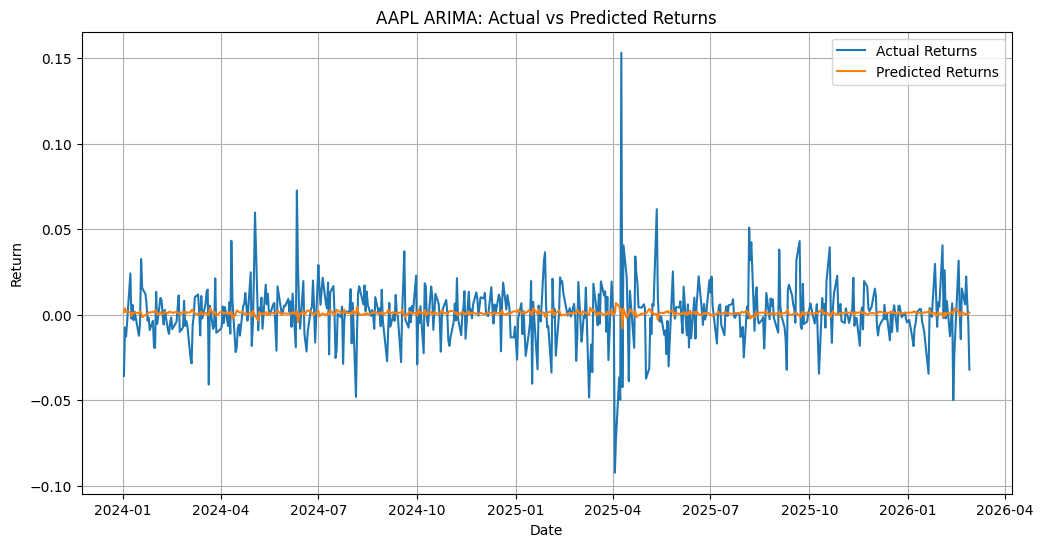

In [48]:
plt.figure(figsize=(12,6))

plt.plot(test_series, label="Actual Returns")
plt.plot(predictions, label="Predicted Returns")

plt.title("AAPL ARIMA: Actual vs Predicted Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid()

plt.show()

Generate Buy/Sell Signals

In [49]:
test['Predicted'] = predictions

test['Signal'] = np.where(test['Predicted'] > 0, "BUY", "SELL")

print(test[['Return', 'Predicted', 'Signal']].head())

              Return  Predicted Signal
Date                                  
2024-01-02 -0.035787   0.001495    BUY
2024-01-03 -0.007488   0.003747    BUY
2024-01-04 -0.012700   0.001597    BUY
2024-01-05 -0.004013   0.001957    BUY
2024-01-08  0.024175   0.001316    BUY


Strategy Returns

In [50]:
strategy_returns = []

for i in range(len(test)):
    
    signal = test['Signal'].iloc[i]
    actual = test['Return'].iloc[i]
    
    if signal == "BUY":
        strategy_returns.append(actual)
    else:
        strategy_returns.append(-actual)

test['Strategy_Return'] = strategy_returns

Portfolio Growth

In [51]:
initial = 1000

test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial

Plot Backtesting Results

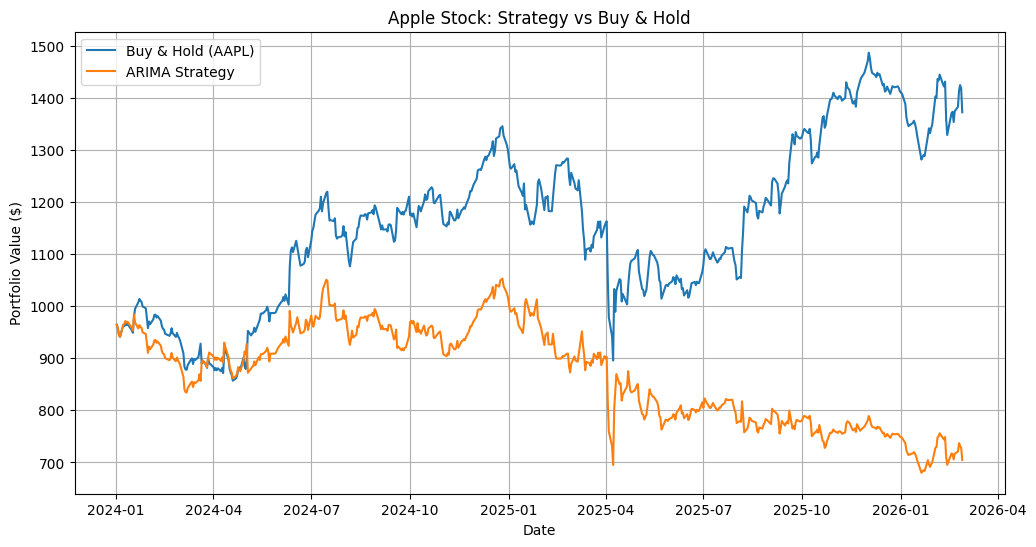

In [52]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Market_Cumulative'], label="Buy & Hold (AAPL)")
plt.plot(test.index, test['Strategy_Cumulative'], label="ARIMA Strategy")

plt.title("Apple Stock: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid()

plt.show()

Final Results Table

In [53]:
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

results = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Market Final Value",
        "Strategy Final Value",
        "Market Profit",
        "Strategy Profit"
    ],
    "Value": [
        1000,
        round(final_market,2),
        round(final_strategy,2),
        round(final_market - 1000,2),
        round(final_strategy - 1000,2)
    ]
})

print(results)

                 Metric    Value
0    Initial Investment  1000.00
1    Market Final Value  1372.15
2  Strategy Final Value   704.66
3         Market Profit   372.15
4       Strategy Profit  -295.34


AMAZON STOCK PREDICTION

Data Loading and Preparation

In [142]:
df = pd.read_csv("../../data/Amazon.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  15.63  15.74  15.35   15.43       15.43  55,664,000
2015-01-05  15.35  15.42  15.04   15.11       15.11  55,484,000
2015-01-06  15.11  15.15  14.62   14.76       14.76  70,380,000
2015-01-07  14.88  15.06  14.77   14.92       14.92  52,806,000
2015-01-08  15.02  15.16  14.81   15.02       15.02  61,768,000


Create Returns

In [60]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close ', 'Adj Close ', 'Volume'], dtype='object')


In [62]:
df.columns = df.columns.str.strip()

In [74]:
df['Return'] = df['Close'].pct_change()

df = df.dropna().copy()

print(df[['Close', 'Return']].head())

            Close    Return
Date                       
2015-01-06  14.76 -0.023163
2015-01-07  14.92  0.010840
2015-01-08  15.02  0.006702
2015-01-09  14.85 -0.011318
2015-01-12  14.57 -0.018855


Train/ Test Split

In [75]:
train = df[df.index < "2024-01-01"].copy()
test = df[df.index >= "2024-01-01"].copy()

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2262
Test size: 541


Walk-Forward ARIMA

In [76]:
def walk_forward_arima(train_series, test_series):
    
    history = list(train_series.copy())
    predictions = []
    
    for t in range(len(test_series)):
        model = ARIMA(history, order=(1,1,1))
        model_fit = model.fit()
        
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        
        history.append(test_series.iloc[t])
    
    return pd.Series(predictions, index=test_series.index)

Train Model & Predict

In [77]:
train_series = train['Return']
test_series = test['Return']

predictions = walk_forward_arima(train_series, test_series)

print(predictions.head())

Date
2024-01-02    0.001060
2024-01-03    0.001070
2024-01-04    0.001022
2024-01-05    0.001234
2024-01-08    0.000755
dtype: float64


Evaluate Model

In [78]:
mae = mean_absolute_error(test_series, predictions)
rmse = np.sqrt(mean_squared_error(test_series, predictions))

directional_accuracy = np.mean(
    (np.sign(predictions) == np.sign(test_series)).astype(int)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("Directional Accuracy:", directional_accuracy)

MAE: 0.01423512217076938
RMSE: 0.019797529191643768
Directional Accuracy: 0.5194085027726433


Plot Actual vs Predicted

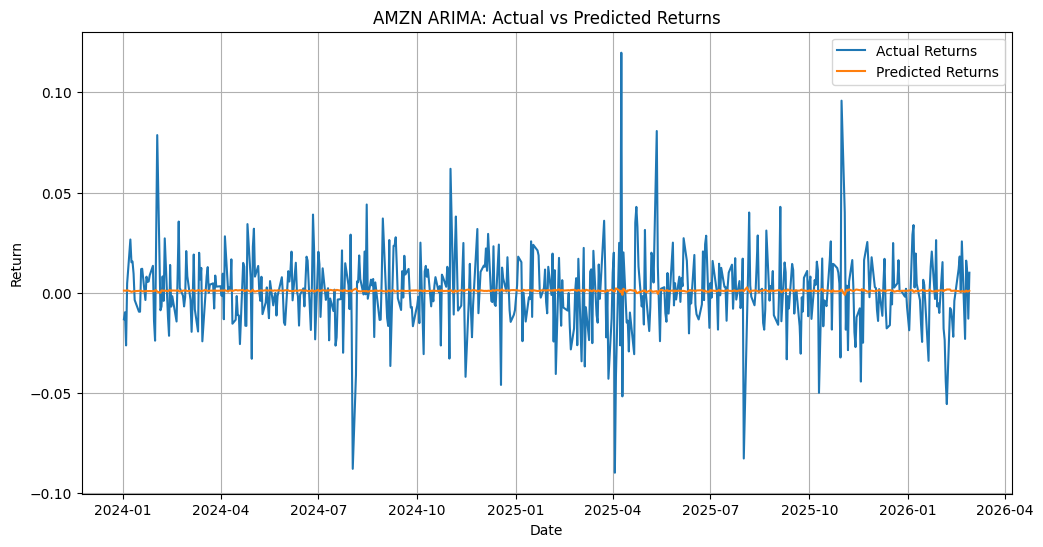

In [79]:
plt.figure(figsize=(12,6))

plt.plot(test_series, label="Actual Returns")
plt.plot(predictions, label="Predicted Returns")

plt.title("AMZN ARIMA: Actual vs Predicted Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid()

plt.show()

Generate Buy/Sell Signals

In [80]:
test['Predicted'] = predictions

test['Signal'] = np.where(test['Predicted'] > 0, "BUY", "SELL")

print(test[['Return', 'Predicted', 'Signal']].head())

              Return  Predicted Signal
Date                                  
2024-01-02 -0.013229   0.001060    BUY
2024-01-03 -0.009738   0.001070    BUY
2024-01-04 -0.026268   0.001022    BUY
2024-01-05  0.004634   0.001234    BUY
2024-01-08  0.026577   0.000755    BUY


Strategy Returns

In [81]:
strategy_returns = []

for i in range(len(test)):
    
    signal = test['Signal'].iloc[i]
    actual = test['Return'].iloc[i]
    
    if signal == "BUY":
        strategy_returns.append(actual)
    else:
        strategy_returns.append(-actual)

test['Strategy_Return'] = strategy_returns

Portfolio Growth

In [82]:
initial = 1000

test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial

Plot Backtesting

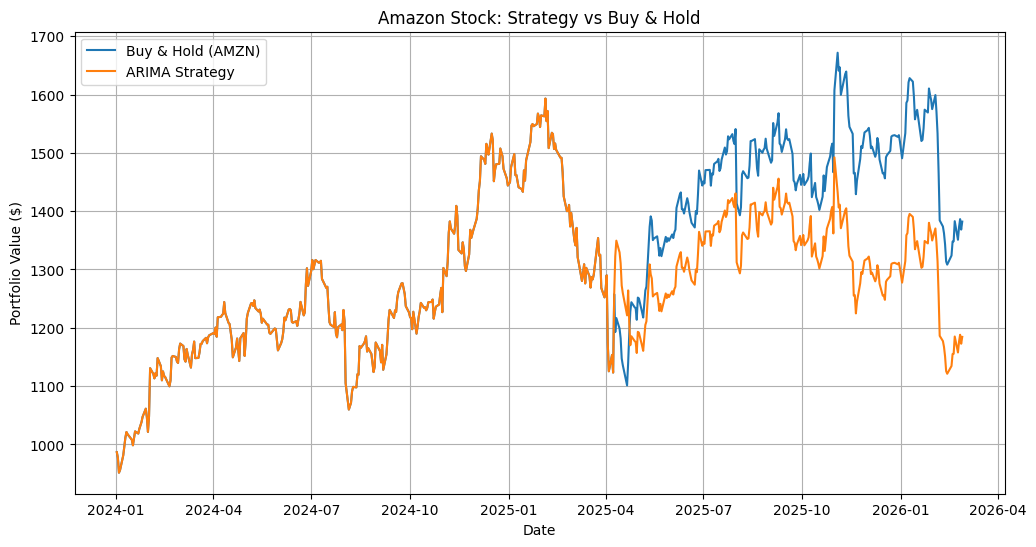

In [83]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Market_Cumulative'], label="Buy & Hold (AMZN)")
plt.plot(test.index, test['Strategy_Cumulative'], label="ARIMA Strategy")

plt.title("Amazon Stock: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid()

plt.show()

Final Profit

In [84]:
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

results = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Market Final Value",
        "Strategy Final Value",
        "Market Profit",
        "Strategy Profit"
    ],
    "Value": [
        1000,
        round(final_market,2),
        round(final_strategy,2),
        round(final_market - 1000,2),
        round(final_strategy - 1000,2)
    ]
})

print(results)

                 Metric    Value
0    Initial Investment  1000.00
1    Market Final Value  1382.12
2  Strategy Final Value  1184.43
3         Market Profit   382.12
4       Strategy Profit   184.43


GOOGLE STOCK PREDICTION

Data Loading and Preparation

In [86]:
df = pd.read_csv("../../data/google.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  26.63  26.79  26.39   26.48       26.28  26,480,000
2015-01-05  26.36  26.40  25.89   25.97       25.78  41,182,000
2015-01-06  26.02  26.06  25.28   25.33       25.14  54,456,000
2015-01-07  25.55  25.57  25.18   25.26       25.07  46,918,000
2015-01-08  25.08  25.38  24.75   25.35       25.16  73,054,000


Create Returns

In [88]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close ', 'Adj Close ', 'Volume'], dtype='object')


In [90]:
df.columns = df.columns.str.strip()

In [91]:
df['Return'] = df['Close'].pct_change()

df = df.dropna().copy()

print(df[['Close','Return']].head())

            Close    Return
Date                       
2015-01-05  25.97 -0.019260
2015-01-06  25.33 -0.024644
2015-01-07  25.26 -0.002764
2015-01-08  25.35  0.003563
2015-01-09  25.04 -0.012229


Train/ Test Split

In [92]:
train = df[df.index < "2024-01-01"].copy()
test = df[df.index >= "2024-01-01"].copy()

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2263
Test size: 541


Walk Forward Arima

In [93]:
def walk_forward_arima(train_series, test_series):
    
    history = list(train_series.copy())
    predictions = []
    
    for t in range(len(test_series)):
        
        model = ARIMA(history, order=(1,1,1))
        model_fit = model.fit()
        
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        
        history.append(test_series.iloc[t])
    
    return pd.Series(predictions, index=test_series.index)

Train Model & Predict

In [94]:
train_series = train['Return']
test_series = test['Return']

predictions = walk_forward_arima(train_series, test_series)

print(predictions.head())

Date
2024-01-02    0.001120
2024-01-03    0.001472
2024-01-04    0.000631
2024-01-05    0.001837
2024-01-08    0.001138
dtype: float64


Evaluate Model

In [95]:
mae = mean_absolute_error(test_series, predictions)
rmse = np.sqrt(mean_squared_error(test_series, predictions))

directional_accuracy = np.mean(
    (np.sign(predictions) == np.sign(test_series)).astype(int)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("Directional Accuracy:", directional_accuracy)

MAE: 0.013596650770332563
RMSE: 0.018765548609325167
Directional Accuracy: 0.5637707948243993


Plot Actual VS Predicted

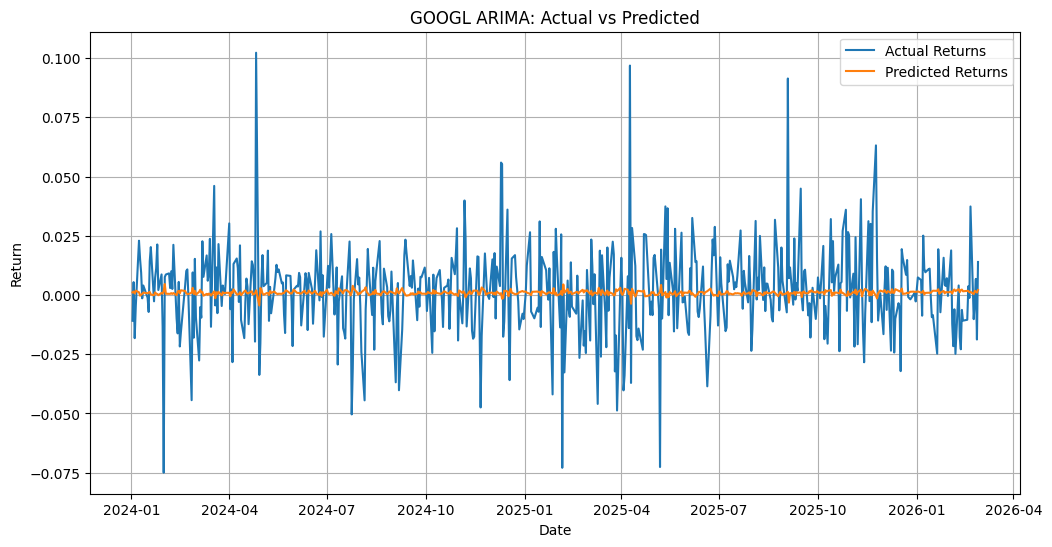

In [96]:
plt.figure(figsize=(12,6))

plt.plot(test_series, label="Actual Returns")
plt.plot(predictions, label="Predicted Returns")

plt.title("GOOGL ARIMA: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid()

plt.show()

Generate Buy/Sell Signals

In [97]:
test['Predicted'] = predictions

test['Signal'] = np.where(test['Predicted'] > 0, "BUY", "SELL")

print(test[['Return','Predicted','Signal']].head())

              Return  Predicted Signal
Date                                  
2024-01-02 -0.010881   0.001120    BUY
2024-01-03  0.005428   0.001472    BUY
2024-01-04 -0.018212   0.000631    BUY
2024-01-05 -0.004839   0.001837    BUY
2024-01-08  0.022913   0.001138    BUY


Strategy Returns

In [98]:
strategy_returns = []

for i in range(len(test)):
    
    signal = test['Signal'].iloc[i]
    actual = test['Return'].iloc[i]
    
    if signal == "BUY":
        strategy_returns.append(actual)
    else:
        strategy_returns.append(-actual)

test['Strategy_Return'] = strategy_returns

Portfolio Growth

In [99]:
initial = 1000

test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial

Backtesting Visualization

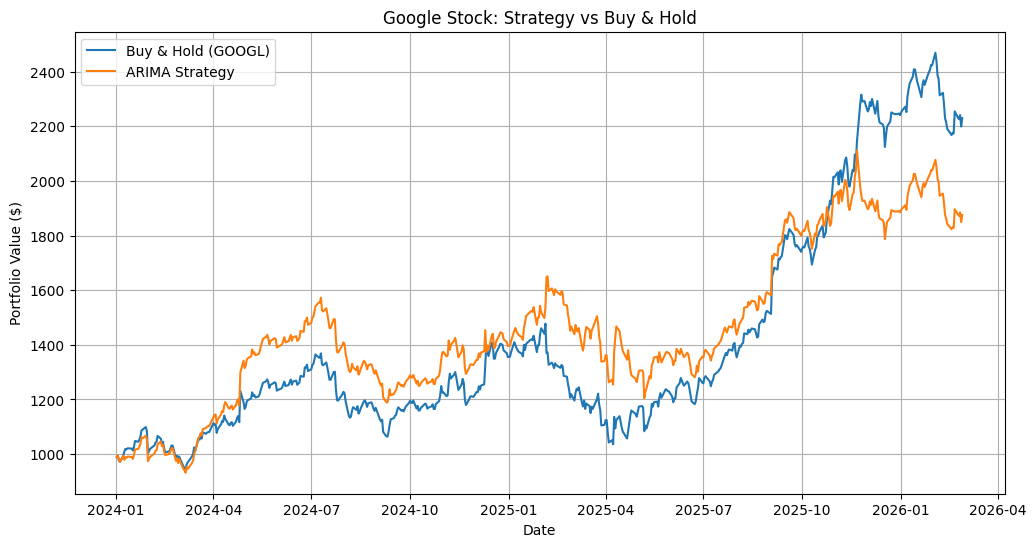

In [100]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Market_Cumulative'], label="Buy & Hold (GOOGL)")
plt.plot(test.index, test['Strategy_Cumulative'], label="ARIMA Strategy")

plt.title("Google Stock: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid()

plt.show()

Final Results Table

In [101]:
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

results = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Market Final Value",
        "Strategy Final Value",
        "Market Profit",
        "Strategy Profit"
    ],
    "Value": [
        1000,
        round(final_market,2),
        round(final_strategy,2),
        round(final_market - 1000,2),
        round(final_strategy - 1000,2)
    ]
})

print(results)

                 Metric    Value
0    Initial Investment  1000.00
1    Market Final Value  2229.44
2  Strategy Final Value  1875.25
3         Market Profit  1229.44
4       Strategy Profit   875.25


MSFT STOCK PREDICTION

Data Loading and Preparation



In [140]:
df = pd.read_csv("../../data/MSFT.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  46.66  47.42  46.54   46.76       39.77  27,913,900
2015-01-05  46.37  46.73  46.25   46.33       39.40  39,673,900
2015-01-06  46.38  46.75  45.54   45.65       38.82  36,447,900
2015-01-07  45.98  46.46  45.49   46.23       39.32  29,114,100
2015-01-08  46.75  47.75  46.72   47.59       40.47  29,645,200


Create Returns

In [104]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close ', 'Adj Close ', 'Volume'], dtype='object')


In [105]:
df.columns = df.columns.str.strip()

In [106]:
df['Return'] = df['Close'].pct_change()

df = df.dropna().copy()

print(df[['Close', 'Return']].head())

            Close    Return
Date                       
2015-01-05  46.33 -0.009196
2015-01-06  45.65 -0.014677
2015-01-07  46.23  0.012705
2015-01-08  47.59  0.029418
2015-01-09  47.19 -0.008405


Train/ Test Split

In [107]:
train = df[df.index < "2024-01-01"].copy()
test = df[df.index >= "2024-01-01"].copy()

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2263
Test size: 541


Walk ForwardArima 

In [108]:
def walk_forward_arima(train_series, test_series):
    
    history = list(train_series.copy())
    predictions = []
    
    for t in range(len(test_series)):
        
        model = ARIMA(history, order=(1,1,1))
        model_fit = model.fit()
        
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        
        history.append(test_series.iloc[t])
    
    return pd.Series(predictions, index=test_series.index)

Train Model & Predict

In [109]:
train_series = train['Return']
test_series = test['Return']

predictions = walk_forward_arima(train_series, test_series)

print(predictions.head())

Date
2024-01-02    0.000905
2024-01-03    0.003222
2024-01-04    0.001293
2024-01-05    0.002236
2024-01-08    0.001251
dtype: float64


Evaluate Model

In [110]:
mae = mean_absolute_error(test_series, predictions)
rmse = np.sqrt(mean_squared_error(test_series, predictions))

directional_accuracy = np.mean(
    (np.sign(predictions) == np.sign(test_series)).astype(int)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("Directional Accuracy:", directional_accuracy)

MAE: 0.010350527449682852
RMSE: 0.01511156637692365
Directional Accuracy: 0.5157116451016636


Plot Actual vs Predicted

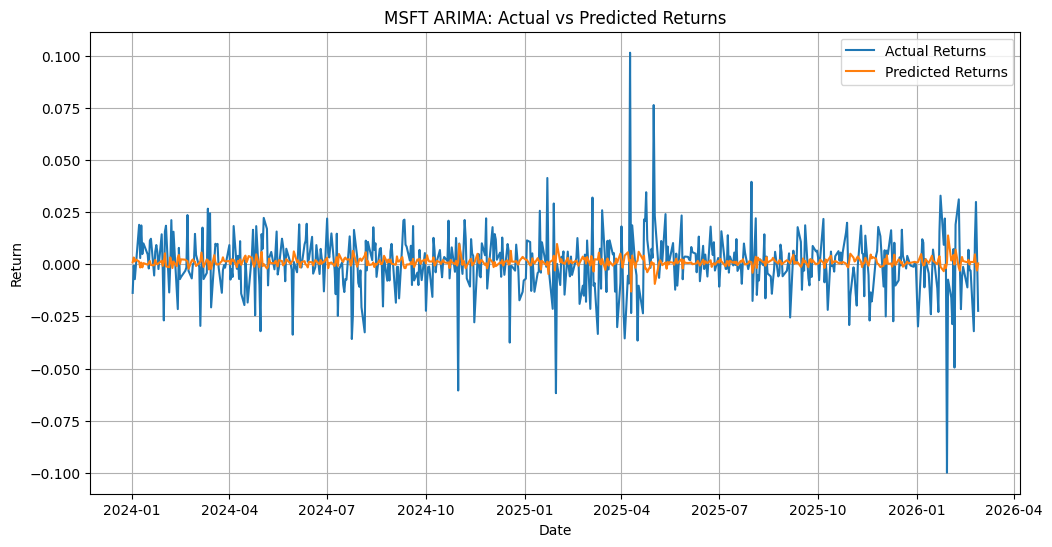

In [111]:
plt.figure(figsize=(12,6))

plt.plot(test_series, label="Actual Returns")
plt.plot(predictions, label="Predicted Returns")

plt.title("MSFT ARIMA: Actual vs Predicted Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid()

plt.show()

Generate Buy/Sell Signals

In [112]:
test['Predicted'] = predictions

test['Signal'] = np.where(test['Predicted'] > 0, "BUY", "SELL")

print(test[['Return', 'Predicted', 'Signal']].head())

              Return  Predicted Signal
Date                                  
2024-01-02 -0.013749   0.000905    BUY
2024-01-03 -0.000728   0.003222    BUY
2024-01-04 -0.007178   0.001293    BUY
2024-01-05 -0.000516   0.002236    BUY
2024-01-08  0.018872   0.001251    BUY


Strategy Returns

In [113]:
strategy_returns = []

for i in range(len(test)):
    
    signal = test['Signal'].iloc[i]
    actual = test['Return'].iloc[i]
    
    if signal == "BUY":
        strategy_returns.append(actual)
    else:
        strategy_returns.append(-actual)

test['Strategy_Return'] = strategy_returns

Portfolio Growth

In [114]:
initial = 1000

test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial

Visualization Backtesting

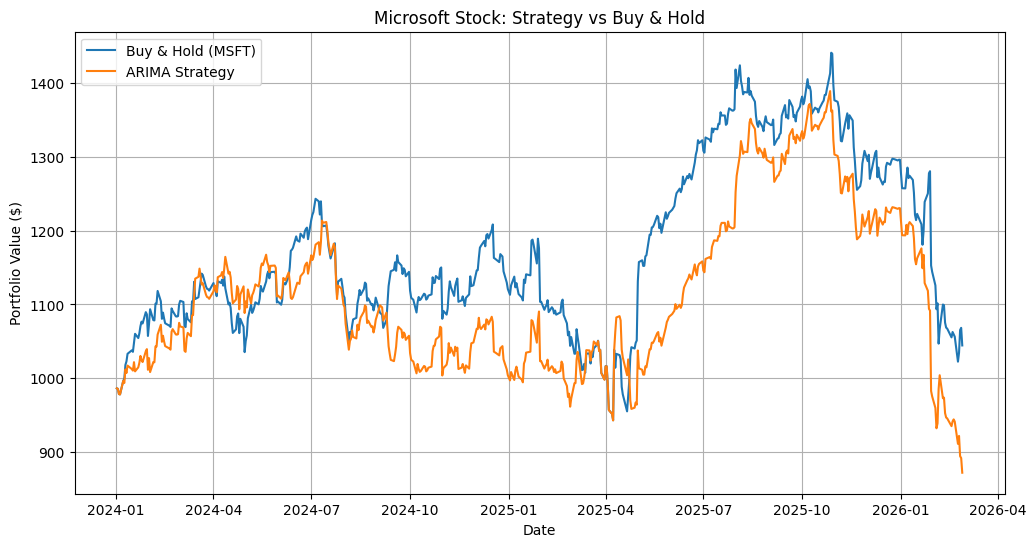

In [115]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Market_Cumulative'], label="Buy & Hold (MSFT)")
plt.plot(test.index, test['Strategy_Cumulative'], label="ARIMA Strategy")

plt.title("Microsoft Stock: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid()

plt.show()

Final Result Table

In [116]:
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

results = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Market Final Value",
        "Strategy Final Value",
        "Market Profit",
        "Strategy Profit"
    ],
    "Value": [
        1000,
        round(final_market,2),
        round(final_strategy,2),
        round(final_market - 1000,2),
        round(final_strategy - 1000,2)
    ]
})

print(results)

                 Metric    Value
0    Initial Investment  1000.00
1    Market Final Value  1044.41
2  Strategy Final Value   871.74
3         Market Profit    44.41
4       Strategy Profit  -128.26


NVIDIA STOCK PREDICTION

Data Loading and Preparation

In [117]:
df = pd.read_csv("../../data/NVIDIA.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

            Open  High   Low  Close   Adj Close        Volume
Date                                                         
2015-01-02  0.50  0.51  0.50    0.50        0.48  113,680,000
2015-01-05  0.50  0.50  0.49    0.49        0.47  197,952,000
2015-01-06  0.50  0.50  0.48    0.48        0.46  197,764,000
2015-01-07  0.48  0.49  0.48    0.48        0.46  321,808,000
2015-01-08  0.48  0.50  0.48    0.50        0.48  283,780,000


Create Returns

In [118]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close ', 'Adj Close ', 'Volume'], dtype='object')


In [119]:
df.columns = df.columns.str.strip()

In [124]:
df['Return'] = df['Close'].pct_change()

df = df.dropna().copy()

print(df[['Close', 'Return']].head())

            Close    Return
Date                       
2015-01-06   0.48 -0.020408
2015-01-07   0.48  0.000000
2015-01-08   0.50  0.041667
2015-01-09   0.50  0.000000
2015-01-12   0.49 -0.020000


Train/ Test Split

In [125]:
train = df[df.index < "2024-01-01"].copy()
test = df[df.index >= "2024-01-01"].copy()

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2262
Test size: 541


Walk Forward Arima Function

In [126]:
def walk_forward_arima(train_series, test_series):
    
    history = list(train_series.copy())
    predictions = []
    
    for t in range(len(test_series)):
        
        model = ARIMA(history, order=(1,1,1))
        model_fit = model.fit()
        
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        
        history.append(test_series.iloc[t])
    
    return pd.Series(predictions, index=test_series.index)

Train Model & Prediction

In [127]:
train_series = train['Return']
test_series = test['Return']

predictions = walk_forward_arima(train_series, test_series)

print(predictions.head())

Date
2024-01-02    0.002703
2024-01-03    0.004621
2024-01-04    0.003555
2024-01-05    0.002037
2024-01-08    0.001069
dtype: float64


Evaluate Model

In [128]:
mae = mean_absolute_error(test_series, predictions)
rmse = np.sqrt(mean_squared_error(test_series, predictions))

directional_accuracy = np.mean(
    (np.sign(predictions) == np.sign(test_series)).astype(int)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("Directional Accuracy:", directional_accuracy)

MAE: 0.02265595140026787
RMSE: 0.031497481175828936
Directional Accuracy: 0.532347504621072


Plot Actual vs Predicted

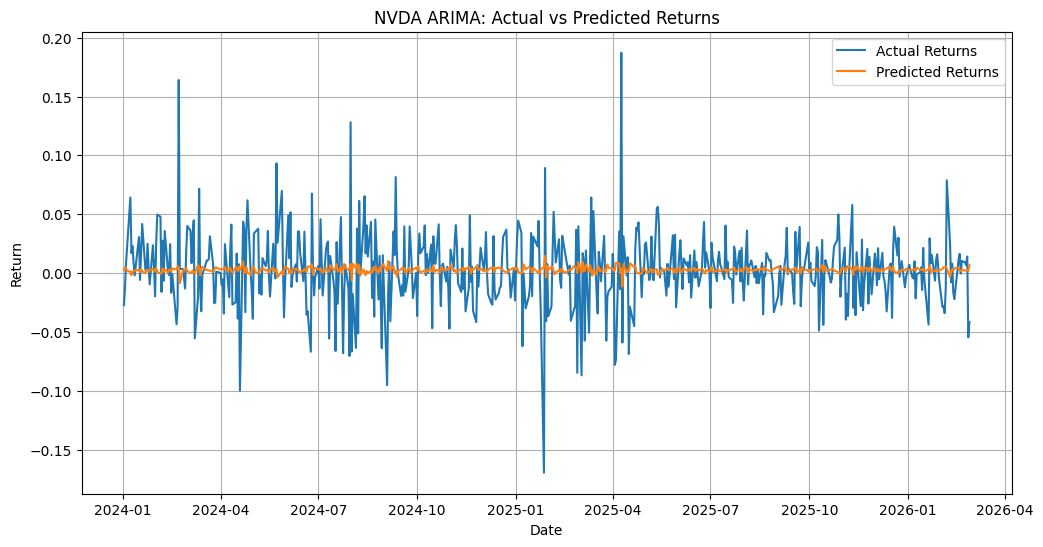

In [129]:
plt.figure(figsize=(12,6))

plt.plot(test_series, label="Actual Returns")
plt.plot(predictions, label="Predicted Returns")

plt.title("NVDA ARIMA: Actual vs Predicted Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid()

plt.show()

Generatte BUY/ Sell Signals

In [130]:
test['Predicted'] = predictions

test['Signal'] = np.where(test['Predicted'] > 0, "BUY", "SELL")

print(test[['Return', 'Predicted', 'Signal']].head())

              Return  Predicted Signal
Date                                  
2024-01-02 -0.027262   0.002703    BUY
2024-01-03 -0.012456   0.004621    BUY
2024-01-04  0.009039   0.003555    BUY
2024-01-05  0.022917   0.002037    BUY
2024-01-08  0.064155   0.001069    BUY


Strategy Returns

In [131]:
strategy_returns = []

for i in range(len(test)):
    
    signal = test['Signal'].iloc[i]
    actual = test['Return'].iloc[i]
    
    if signal == "BUY":
        strategy_returns.append(actual)
    else:
        strategy_returns.append(-actual)

test['Strategy_Return'] = strategy_returns

Portfolio Growth

In [132]:
initial = 1000

test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial

Plot Backtesting Results

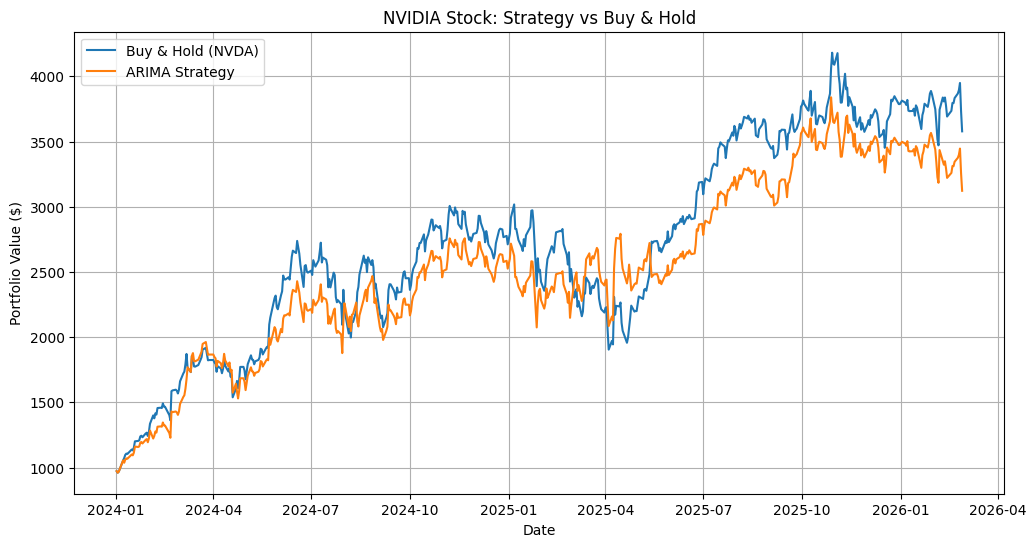

In [133]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Market_Cumulative'], label="Buy & Hold (NVDA)")
plt.plot(test.index, test['Strategy_Cumulative'], label="ARIMA Strategy")

plt.title("NVIDIA Stock: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid()

plt.show()

Final Profit Table

In [134]:
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

results = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Market Final Value",
        "Strategy Final Value",
        "Market Profit",
        "Strategy Profit"
    ],
    "Value": [
        1000,
        round(final_market,2),
        round(final_strategy,2),
        round(final_market - 1000,2),
        round(final_strategy - 1000,2)
    ]
})

print(results)

                 Metric    Value
0    Initial Investment  1000.00
1    Market Final Value  3578.15
2  Strategy Final Value  3122.26
3         Market Profit  2578.15
4       Strategy Profit  2122.26
